In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)

In [8]:
df_inversion_family_scored = pd.read_csv('../classification_model/data/processed/df_inversion_family_scored.csv', sep=',')
df_pension_plan_scored = pd.read_csv('../classification_model/data/processed/df_pension_plan_scored.csv', sep=',')
df_payment_card_scored = pd.read_csv('../classification_model/data/processed/df_payment_card_scored.csv', sep=',')

df_clustering = pd.read_csv('../clustering/data/processed/df_clustered.csv', sep=',')


In [9]:
df_inversion_family_scored.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_pension_plan_scored.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_payment_card_scored.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

df_clustering.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Use Case

## 1. Campaign target selection

In [10]:
df_payment_card_scored

,pk_cid,credit_card,debit_card,have_paymentcards_products,propensity_score,propensity_segment
0,1000096,0,0,0,0.000009,Low
1,1000113,0,0,0,0.000027,Low
2,1000130,0,0,0,0.000308,Low
3,1000157,0,0,0,0.000009,Low
4,1000162,0,0,0,0.000040,Low
...,...,...,...,...,...,...
393751,998325,0,0,0,0.000010,Low
393752,998837,0,0,0,0.001594,Low
393753,999706,0,0,0,0.001704,Low
393754,999825,0,0,0,0.000013,Low


In [12]:
df_pension_plan_scored.rename(columns={"propensity_segment":"propensity_segment_pensionplan", "propensity_score":"propensity_score_pensionplan"}, inplace=True)
df_inversion_family_scored.rename(columns={"propensity_segment":"propensity_segment_investment", "propensity_score":"propensity_score_investment"}, inplace=True)
df_payment_card_scored.rename(columns={"propensity_segment":"propensity_segment_paymentcard", "propensity_score":"propensity_score_paymentcard"}, inplace=True)


df_union = df_clustering.merge(df_pension_plan_scored, on ='pk_cid', how='left')
df_union = df_union.merge(df_inversion_family_scored, on='pk_cid', how='left')
df_union = df_union.merge(df_payment_card_scored, on='pk_cid', how='left')

df_union = df_union[['pk_cid','cluster_name','propensity_segment_pensionplan','propensity_score_pensionplan','propensity_segment_investment','propensity_score_investment', 'have_inversion_products', 'propensity_segment_paymentcard','propensity_score_paymentcard','have_paymentcards_products']].drop_duplicates()

In [13]:
df_union

,pk_cid,cluster_name,propensity_segment_pensionplan,propensity_score_pensionplan,propensity_segment_investment,propensity_score_investment,have_inversion_products,propensity_segment_paymentcard,propensity_score_paymentcard,have_paymentcards_products
0,1000028,Particulares Premium Digitales,Low,0.000021,Low,0.000174,0.0,NaN,NaN,NaN
1,1000096,Particulares sin cuenta,Low,0.000029,Low,0.000064,0.0,Low,0.000009,0.0
2,1000113,Particulares sin cuenta,Low,0.000024,Low,0.000052,0.0,Low,0.000027,0.0
3,1000130,Particulares sin cuenta,Low,0.000101,Low,0.000226,0.0,Low,0.000308,0.0
4,1000157,Particulares Premium Digitales,Low,0.000014,Low,0.000028,0.0,Low,0.000009,0.0
...,...,...,...,...,...,...,...,...,...,...
442904,998859,Particulares Premium Digitales,NaN,NaN,Low,0.000039,0.0,NaN,NaN,NaN
442905,999706,Particulares sin cuenta,Low,0.007068,Low,0.001197,0.0,Low,0.001704,0.0
442906,999825,Particulares Premium Digitales,Low,0.000024,Low,0.000030,0.0,Low,0.000013,0.0
442907,999835,Particulares Premium Digitales,Low,0.000035,NaN,NaN,NaN,Low,0.000009,0.0


propensity_segment_pensionplan,High,Low,Medium,Mid-Low,Top
cluster_name,,,,,
Jóvenes Básicos Activos,120,44428,121,41,316
Jóvenes Potenciales,405,107871,109,59,1311
Jóvenes Recientes,195,73134,128,62,351
Leads Jóvenes,1197,60838,916,248,572
Particulares Premium Digitales,3226,72618,1093,419,5853
Particulares sin cuenta,631,45186,884,590,226


propensity_segment_investment,High,Low,Medium,Mid-Low,Top
cluster_name,,,,,
Jóvenes Básicos Activos,80,44716,27,39,311
Jóvenes Potenciales,301,111831,150,165,834
Jóvenes Recientes,109,73538,45,53,333
Leads Jóvenes,481,61613,184,111,1355
Particulares Premium Digitales,2658,78971,1126,1197,4352
Particulares sin cuenta,528,44756,287,371,842


propensity_segment_paymentcard,High,Low,Medium,Mid-Low,Top
cluster_name,,,,,
Jóvenes Básicos Activos,170,43057,53,34,320
Jóvenes Potenciales,468,104208,62,47,1143
Jóvenes Recientes,177,70528,40,44,450
Leads Jóvenes,1356,61085,203,106,928
Particulares Premium Digitales,1450,53753,202,175,6628
Particulares sin cuenta,495,45322,355,591,306


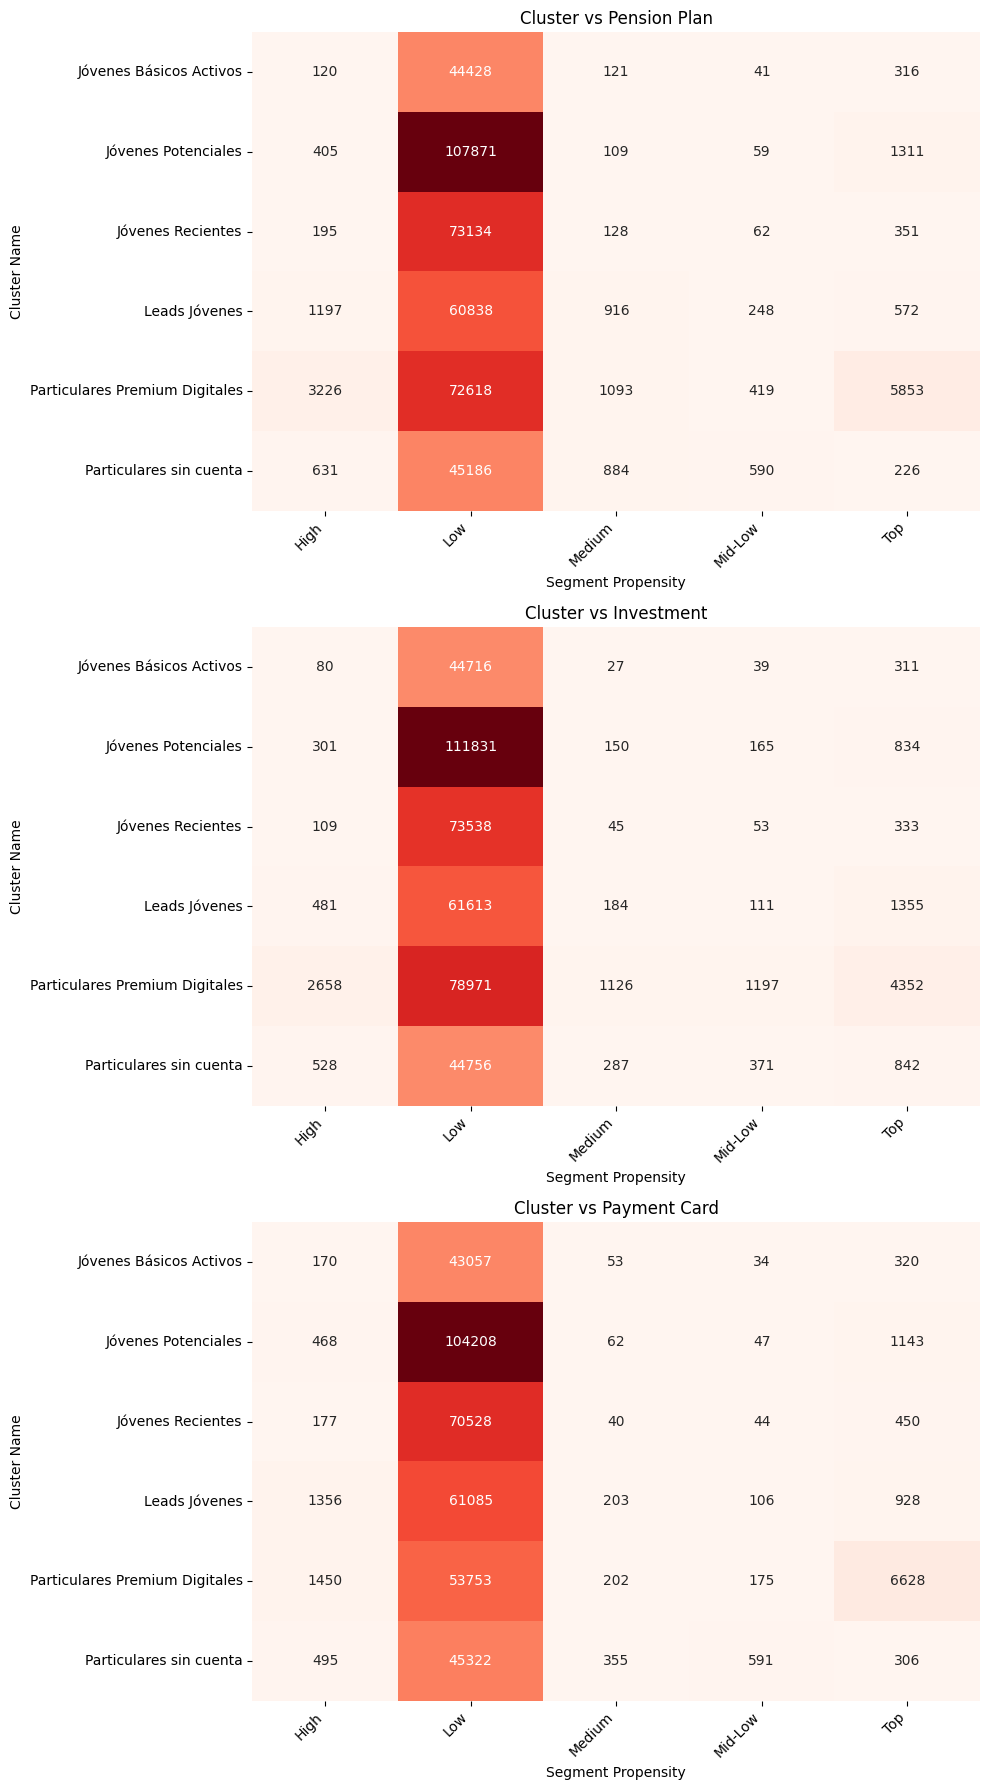

In [15]:
segmentos = {
    "Pension Plan": "propensity_segment_pensionplan",
    "Investment": "propensity_segment_investment",
    "Payment Card": "propensity_segment_paymentcard"
}

fig, axs = plt.subplots(len(segmentos), 1, figsize=(10, 6 * len(segmentos)))

if len(segmentos) == 1:
    axs = [axs]

for i, (titulo, columna_segmento) in enumerate(segmentos.items()):
    
    df_tmp = df_union.copy()

    df_tmp = df_tmp.dropna(subset=[columna_segmento])

    tabla = pd.crosstab(df_tmp['cluster_name'], df_tmp[columna_segmento])
    display(tabla)

    sns.heatmap(tabla, annot=True, cmap="Reds", fmt='d', cbar=False, ax=axs[i])

    axs[i].set_title(f"Cluster vs {titulo}")
    axs[i].set_xlabel("Segment Propensity")
    axs[i].set_ylabel("Cluster Name")
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45, ha="right")
    axs[i].set_yticklabels(axs[i].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Filas usadas en Pension Plan: 19073


propensity_segment_pensionplan,High,Medium,Mid-Low,Top
cluster_name,,,,
Jóvenes Básicos Activos,120,121,41,316
Jóvenes Potenciales,405,109,59,1311
Jóvenes Recientes,195,128,62,351
Leads Jóvenes,1197,916,248,572
Particulares Premium Digitales,3226,1093,419,5853
Particulares sin cuenta,631,884,590,226


Filas usadas en Investment: 15939


propensity_segment_investment,High,Medium,Mid-Low,Top
cluster_name,,,,
Jóvenes Básicos Activos,80,27,39,311
Jóvenes Potenciales,301,150,165,834
Jóvenes Recientes,109,45,53,333
Leads Jóvenes,481,184,111,1355
Particulares Premium Digitales,2658,1126,1197,4352
Particulares sin cuenta,528,287,371,842


Filas usadas en Payment Card: 15803


propensity_segment_paymentcard,High,Medium,Mid-Low,Top
cluster_name,,,,
Jóvenes Básicos Activos,170,53,34,320
Jóvenes Potenciales,468,62,47,1143
Jóvenes Recientes,177,40,44,450
Leads Jóvenes,1356,203,106,928
Particulares Premium Digitales,1450,202,175,6628
Particulares sin cuenta,495,355,591,306


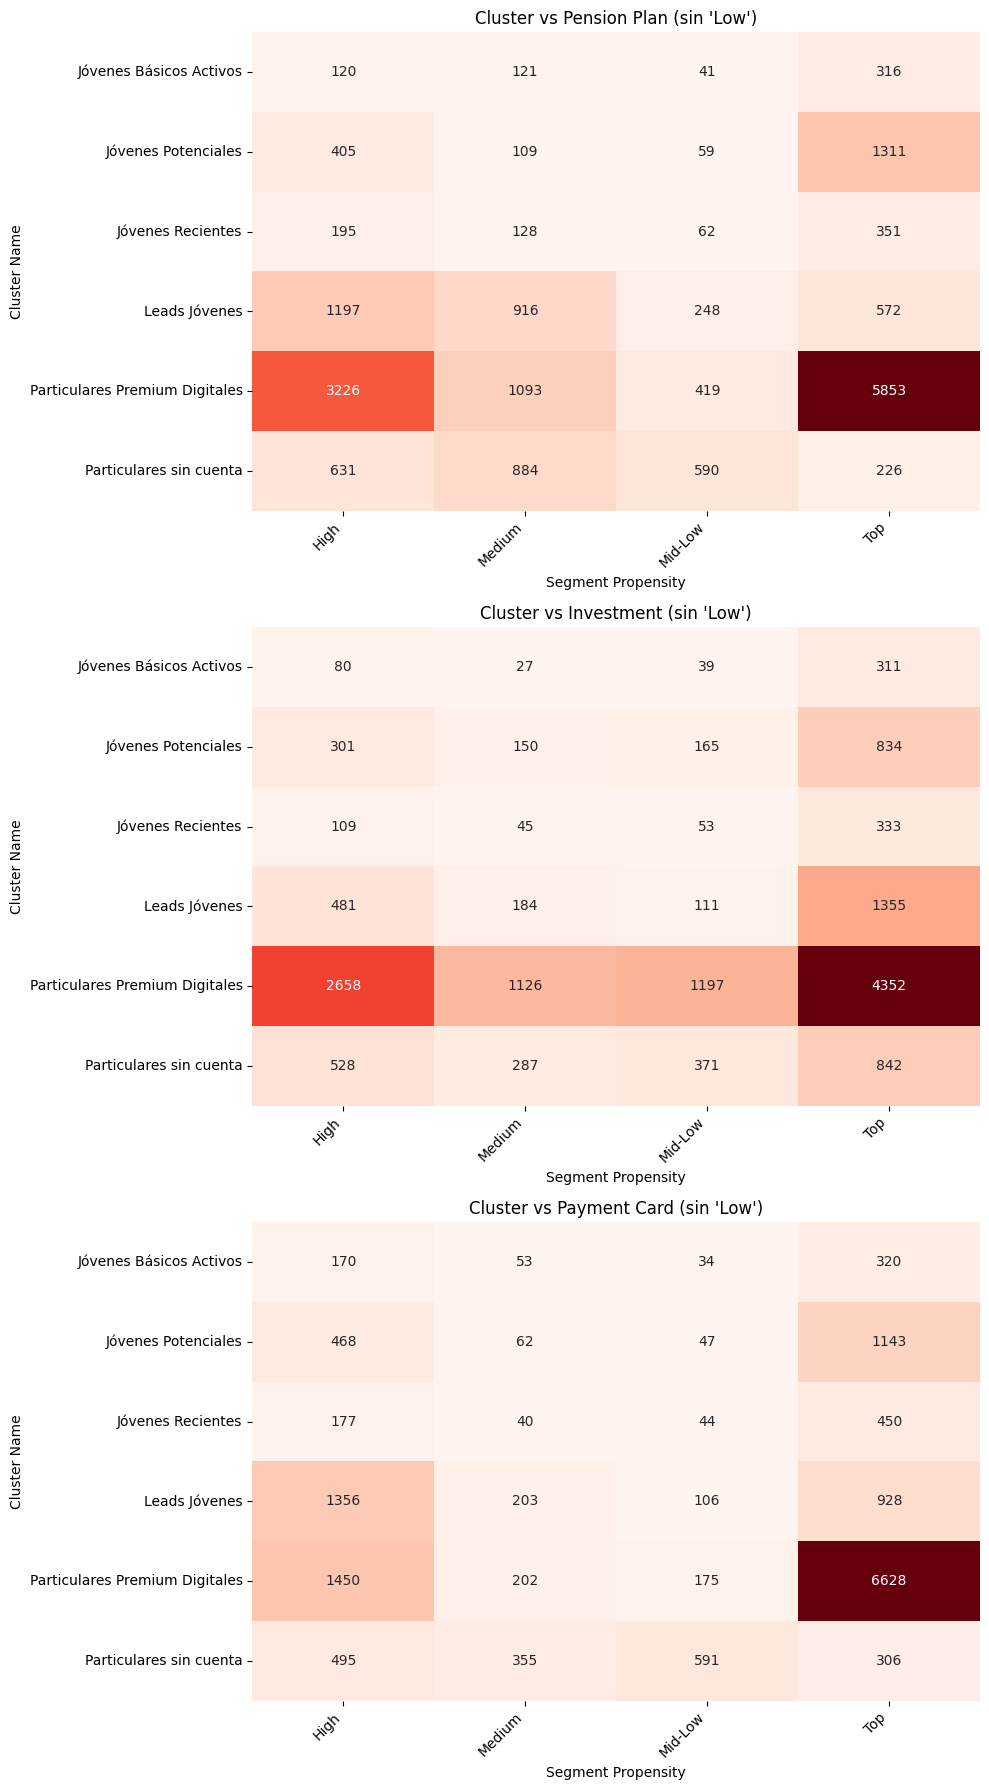

In [16]:
segmentos = {
    "Pension Plan": "propensity_segment_pensionplan",
    "Investment": "propensity_segment_investment",
    "Payment Card": "propensity_segment_paymentcard"
}

fig, axs = plt.subplots(len(segmentos), 1, figsize=(10, 6 * len(segmentos)))

if len(segmentos) == 1:
    axs = [axs]

for i, (titulo, columna_segmento) in enumerate(segmentos.items()):
    
    df_tmp = df_union.copy()

    # Eliminamos NA y los casos "Low"
    df_tmp = df_tmp.dropna(subset=[columna_segmento])
    df_tmp = df_tmp[df_tmp[columna_segmento] != "Low"]

    print(f"Filas usadas en {titulo}: {df_tmp.shape[0]}")

    # Crear tabla cruzada cluster_name vs segmento (sin "Low")
    tabla = pd.crosstab(df_tmp['cluster_name'], df_tmp[columna_segmento])
    display(tabla)

    sns.heatmap(tabla, annot=True, cmap="Reds", fmt='d', cbar=False, ax=axs[i])

    axs[i].set_title(f"Cluster vs {titulo} (sin 'Low')")
    axs[i].set_xlabel("Segment Propensity")
    axs[i].set_ylabel("Cluster Name")
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45, ha="right")
    axs[i].set_yticklabels(axs[i].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 2. Margin analysis

In [17]:
df_sales = pd.read_csv('../data/datasets_TFM + diccionario/sales.csv', sep=',')
df_products = pd.read_csv('../data/datasets_TFM + diccionario/product_description.csv', sep=',')



In [18]:
df_sales = df_sales[df_sales["month_sale"]=='2019-05-01'][['product_ID','net_margin']]
df_sales = df_sales.groupby('product_ID').agg({'net_margin':'mean'}).reset_index()
df_sales

,product_ID,net_margin
0,1119,1727.652941
1,1364,6071.558669
2,2234,69.576027
3,2235,69.002133
4,2312,59.833333
5,2336,1992.950000
6,2673,1375.783333
7,3819,60.015569
8,4657,70.555493
9,8871,69.879158


In [19]:
df_margin = df_sales.merge(df_products[['pk_product_ID','product_desc', 'family_product']], left_on='product_ID',  right_on='pk_product_ID', how='left') 
df_margin = df_margin.groupby('family_product').agg({'net_margin':'mean'}).reset_index()
df_margin

,family_product,net_margin
0,account,69.753203
1,investment,1698.795425
2,payment_card,59.924451
3,pension_plan,6071.558669
